# RetainAI — Block 3: NLP, Semi-Supervised Learning, Deep Learning, LLM Data Curation

Customers tell you they're about to leave *in words* before they do it. This block builds:

1. **Intent classifier** for support messages, with churn-signal intents flagged for the agent (Block 4)
2. **Semi-supervised experiment**: how much does self-training help when labels are scarce?
3. **Deep learning**: fine-tuned DistilBERT vs TF-IDF with the same small labeled set
4. **Curated LLM fine-tuning dataset**: cleaned, deduplicated, balanced, documented with a data card

Dataset: Bitext customer support dataset (~27K support messages, 27 intents) from Hugging Face.

In [1]:
%pip install -q datasets transformers scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Load and explore

Found: ['Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv']


Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

26,872 messages | 27 intents | 11 categories


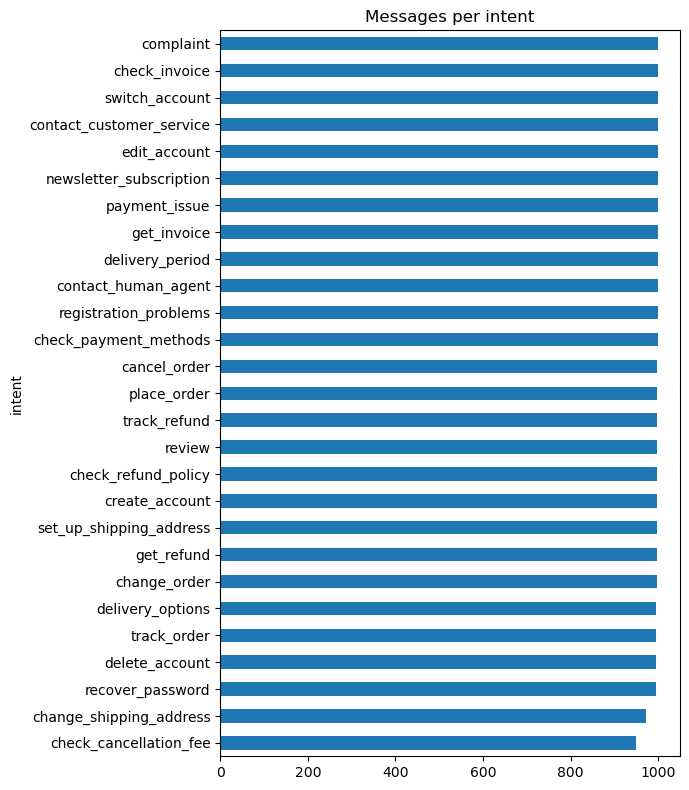

,instruction,intent
4476,how can I check bill #12588?,check_invoice
676,I'm rtying to cancel order {{Order Number}},cancel_order
16877,I do not know what to do to demand my money back,get_refund
26429,assistance to see if there are any news on the...,track_refund
22508,I don't know how t leave an opinion about a pr...,review


In [4]:
import os, re, json, time, warnings, joblib
os.environ["SAGEMAKER_SUPPRESS_V2_WARNING"] = "1"
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
os.makedirs("artifacts", exist_ok=True); os.makedirs("docs", exist_ok=True)

from huggingface_hub import list_repo_files, hf_hub_download
DATASET = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
files = [f for f in list_repo_files(DATASET, repo_type="dataset") if f.endswith((".csv", ".parquet"))]
print("Found:", files)
path = hf_hub_download(DATASET, files[0], repo_type="dataset")
df = pd.read_csv(path) if path.endswith(".csv") else pd.read_parquet(path)

needed = {"instruction", "intent", "category", "response"}
assert needed.issubset(df.columns), f"Unexpected columns: {df.columns.tolist()}"
df = df.dropna(subset=list(needed)).reset_index(drop=True)
print(f"{len(df):,} messages | {df['intent'].nunique()} intents | {df['category'].nunique()} categories")

df["intent"].value_counts().sort_values().plot.barh(figsize=(7, 8), title="Messages per intent")
plt.tight_layout(); plt.savefig("artifacts/intent_distribution.png", dpi=120); plt.show()
df[["instruction", "intent"]].sample(5, random_state=1)

## 2. Map intents to churn signals

Some intents are early warnings of churn. The agent in Block 4 will treat these as risk signals.

In [5]:
CHURN_SIGNALS = {"delete_account", "cancel_order", "complaint", "check_cancellation_fee",
                 "get_refund", "track_refund", "payment_issue", "contact_human_agent"}
churn_intents = sorted(CHURN_SIGNALS & set(df["intent"]))
print("Churn-signal intents in data:", churn_intents)
print(f"Share of messages that are churn signals: {df['intent'].isin(churn_intents).mean():.1%}")

Churn-signal intents in data: ['cancel_order', 'check_cancellation_fee', 'complaint', 'contact_human_agent', 'delete_account', 'get_refund', 'payment_issue', 'track_refund']
Share of messages that are churn signals: 29.5%


## 3. Hold out a test set (never used for training or self-training)

In [6]:
from sklearn.model_selection import train_test_split

pool, test = train_test_split(df, test_size=0.2, stratify=df["intent"], random_state=42)
labels = sorted(df["intent"].unique())
label2id = {l: i for i, l in enumerate(labels)}
y_pool = pool["intent"].map(label2id).values
y_test = test["intent"].map(label2id).values
print(f"Pool: {len(pool):,} | Test: {len(test):,}")

Pool: 21,497 | Test: 5,375


## 4. Semi-supervised learning: self-training with scarce labels

Real support teams have millions of messages but only a few hundred labeled ones.
We simulate that: keep labels for a small fraction of the pool, hide the rest, and compare:

- **Supervised baseline**: train only on the labeled fraction
- **Naive self-training** (scikit-learn, top-k most confident): pseudo-label the unlabeled messages, retrain, repeat
- **Class-balanced self-training** (implemented here): each round, add the most confident predictions *per class*,
  growing every class equally so no single class can take over
- **Upper bound**: all labels available

Because the hidden labels are known, we can also measure how accurate the pseudo-labels were.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import accuracy_score, f1_score

vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit(pool["instruction"])
X_pool, X_test = vec.transform(pool["instruction"]), vec.transform(test["instruction"])

def lr():
    return LogisticRegression(max_iter=3000, C=10)

def labeled_mask(frac, seed=42):
    picked = pool.groupby("intent").sample(frac=frac, random_state=seed).index
    return np.isin(pool.index, picked)

def balanced_self_training(X, y_semi, rounds=5):
    """Each round: train, then pseudo-label the k most confident unlabeled examples PER CLASS,
    where k = current average class size (so the labeled set roughly doubles each round)."""
    y = y_semi.copy()
    classes = np.unique(y[y >= 0])
    for _ in range(rounds):
        clf = lr().fit(X[y >= 0], y[y >= 0])
        unlabeled = np.where(y < 0)[0]
        if len(unlabeled) == 0:
            break
        proba = clf.predict_proba(X[unlabeled])
        pred, conf = clf.classes_[proba.argmax(1)], proba.max(1)
        k = max(1, int((y >= 0).sum() / len(classes)))
        for c in classes:
            idx = np.where(pred == c)[0]
            y[unlabeled[idx[np.argsort(-conf[idx])[:k]]]] = c
    return lr().fit(X[y >= 0], y[y >= 0]), y

rows = []
for frac in [0.005, 0.01, 0.02, 0.05]:
    mask = labeled_mask(frac)
    y_semi = np.where(mask, y_pool, -1)                                   # -1 = unlabeled

    base = lr().fit(X_pool[mask], y_pool[mask])
    naive = SelfTrainingClassifier(lr(), criterion="k_best", k_best=int(mask.sum() / 2) + 1, max_iter=10)
    naive.fit(X_pool, y_semi)
    balanced, y_new = balanced_self_training(X_pool, y_semi)

    pseudo = (y_new >= 0) & ~mask
    rows.append({
        "label_fraction": frac, "labeled_examples": int(mask.sum()),
        "supervised_acc": accuracy_score(y_test, base.predict(X_test)),
        "naive_self_training_acc": accuracy_score(y_test, naive.predict(X_test)),
        "balanced_self_training_acc": accuracy_score(y_test, balanced.predict(X_test)),
        "pseudo_labels_added": int(pseudo.sum()),
        "pseudo_label_accuracy": (y_new[pseudo] == y_pool[pseudo]).mean(),
    })
    r = rows[-1]
    print(f"{frac:>5.1%} labels ({r['labeled_examples']:>4}): supervised {r['supervised_acc']:.3f} | "
          f"naive ST {r['naive_self_training_acc']:.3f} | balanced ST {r['balanced_self_training_acc']:.3f}")

full_acc = accuracy_score(y_test, lr().fit(X_pool, y_pool).predict(X_test))
semi = pd.DataFrame(rows)
print(f"Upper bound (100% labels, {len(pool):,} examples): {full_acc:.3f}")
semi.round(3)

 0.5% labels ( 108): supervised 0.698 | naive ST 0.604 | balanced ST 0.757
 1.0% labels ( 216): supervised 0.821 | naive ST 0.785 | balanced ST 0.842
 2.0% labels ( 431): supervised 0.906 | naive ST 0.880 | balanced ST 0.914


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(semi["labeled_examples"], semi["supervised_acc"], "o-", label="Supervised only")
plt.plot(semi["labeled_examples"], semi["naive_self_training_acc"], "x--", label="Naive self-training")
plt.plot(semi["labeled_examples"], semi["balanced_self_training_acc"], "s-", label="Class-balanced self-training")
plt.axhline(full_acc, ls="--", c="gray", label="All labels")
plt.xscale("log"); plt.xlabel("Labeled examples (log scale)"); plt.ylabel("Test accuracy")
plt.title("Semi-supervised learning with scarce labels"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("artifacts/semi_supervised_curve.png", dpi=120); plt.show()

## 5. Deep learning: fine-tune DistilBERT on the same small labeled set

Transformers bring pretrained knowledge of language. Do they beat TF-IDF when labels are scarce?
Runs on CPU in a few minutes on ml.m5.xlarge (much faster on a GPU instance).

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

torch.manual_seed(42)
torch.set_num_threads(os.cpu_count())
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_NAME = "distilbert-base-uncased"
DL_FRAC, EPOCHS, BATCH, MAX_LEN, LR = 0.02, 10, 16, 64, 5e-5

dl_train = pool.groupby("intent").sample(frac=DL_FRAC, random_state=42)
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(labels),
    id2label={i: l for l, i in label2id.items()}, label2id=label2id,
).to(device)

def encode(texts):
    enc = tok(list(texts), truncation=True, padding="max_length", max_length=MAX_LEN, return_tensors="pt")
    return enc["input_ids"], enc["attention_mask"]

ids, att = encode(dl_train["instruction"])
y_dl = torch.tensor(dl_train["intent"].map(label2id).values)
loader = DataLoader(TensorDataset(ids, att, y_dl), batch_size=BATCH, shuffle=True)

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = EPOCHS * len(loader)
sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: max(0.0, 1 - s / total_steps))  # linear decay

print(f"Fine-tuning on {len(dl_train)} examples, {total_steps} steps, device={device}")
model.train(); t0 = time.time()
for epoch in range(EPOCHS):
    running = 0.0
    for b_ids, b_att, b_y in loader:
        out = model(input_ids=b_ids.to(device), attention_mask=b_att.to(device), labels=b_y.to(device))
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step(); opt.zero_grad()
        running += out.loss.item()
    print(f"epoch {epoch + 1}/{EPOCHS}  loss {running / len(loader):.3f}  ({time.time() - t0:.0f}s)")
train_seconds = time.time() - t0

In [ ]:
model.eval()
t_ids, t_att = encode(test["instruction"])
preds = []
with torch.no_grad():
    for i in range(0, len(t_ids), 128):
        logits = model(input_ids=t_ids[i:i + 128].to(device), attention_mask=t_att[i:i + 128].to(device)).logits
        preds += logits.argmax(-1).cpu().tolist()

acc_dl = accuracy_score(y_test, preds)
f1_dl = f1_score(y_test, preds, average="macro")

# Fair comparison: TF-IDF + logistic regression on the SAME labeled examples
same = lr().fit(vec.transform(dl_train["instruction"]), dl_train["intent"].map(label2id))
p_tfidf = same.predict(X_test)
acc_tfidf, f1_tfidf = accuracy_score(y_test, p_tfidf), f1_score(y_test, p_tfidf, average="macro")

comparison = pd.DataFrame({
    "model": ["TF-IDF + LogReg", "DistilBERT (fine-tuned)"],
    "labeled_examples": [len(dl_train)] * 2,
    "accuracy": [acc_tfidf, acc_dl], "macro_f1": [f1_tfidf, f1_dl],
})
print(f"Fine-tuning time: {train_seconds:.0f}s on {device}")
comparison.round(4)

## 6. Production intent model (used by the agent in Block 4)

For serving, a TF-IDF model trained on all labels is accurate, tiny, and runs in milliseconds without a GPU.
Choosing the simpler model when it's good enough is an engineering decision worth documenting.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

intent_clf = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True), lr())
intent_clf.fit(pool["instruction"], pool["intent"])
pred_test = intent_clf.predict(test["instruction"])
prod_acc = accuracy_score(test["intent"], pred_test)
print(f"Production intent model test accuracy: {prod_acc:.4f}\n")
print(classification_report(test["intent"], pred_test, labels=churn_intents, digits=3))

joblib.dump({"pipeline": intent_clf, "churn_signals": churn_intents}, "artifacts/intent_model.joblib")

for msg in ["I want to close my account, third outage this month",
            "where can I see my last bill",
            "you charged me twice and nobody is helping"]:
    intent = intent_clf.predict([msg])[0]
    print(f"{msg!r:55} -> {intent}{'  ⚠ churn signal' if intent in churn_intents else ''}")

## 7. Curate an LLM fine-tuning dataset

Turn raw instruction/response pairs into a clean, balanced, documented dataset in chat format,
ready for fine-tuning a support model (e.g., on Amazon Bedrock or SageMaker).
Every filtering step is logged so the dataset is reproducible and auditable.

In [ ]:
CAP_PER_INTENT = 600
SYSTEM_PROMPT = ("You are a helpful, empathetic customer support assistant. "
                 "Resolve the customer's issue clearly and concisely.")

cur = df[["instruction", "response", "intent", "category"]].copy()
log = {"raw": len(cur)}

cur["instruction"] = cur["instruction"].str.strip()
cur["response"] = cur["response"].str.strip()

# 1) Near-duplicate removal: normalize case, punctuation and whitespace before comparing
normalize = lambda s: re.sub(r"\s+", " ", re.sub(r"[^\w\s]", "", s.lower())).strip()
cur["key"] = cur["instruction"].map(normalize)
cur = cur.drop_duplicates(subset="key")
log["after_dedup"] = len(cur)

# 2) Length filters: drop fragments and runaway responses
n_in, n_out = cur["instruction"].str.split().str.len(), cur["response"].str.split().str.len()
cur = cur[n_in.between(3, 80) & n_out.between(20, 400)]
log["after_length_filter"] = len(cur)

# 3) Balance: cap each intent so frequent intents don't dominate
cur = cur.sample(frac=1, random_state=42).groupby("intent").head(CAP_PER_INTENT)
log["after_balancing"] = len(cur)

# Placeholders like {{Order Number}} are intentional template slots: keep, but measure
placeholder_share = cur["response"].str.contains(r"\{\{").mean()

ft_train, ft_val = train_test_split(cur, test_size=0.05, stratify=cur["intent"], random_state=42)
os.makedirs("artifacts/llm_dataset", exist_ok=True)

def to_jsonl(frame, path):
    with open(path, "w") as f:
        for _, r in frame.iterrows():
            f.write(json.dumps({"messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": r["instruction"]},
                {"role": "assistant", "content": r["response"]},
            ], "metadata": {"intent": r["intent"], "category": r["category"]}}) + "\n")

to_jsonl(ft_train, "artifacts/llm_dataset/train.jsonl")
to_jsonl(ft_val, "artifacts/llm_dataset/validation.jsonl")
log.update({"train": len(ft_train), "validation": len(ft_val)})
print(json.dumps(log, indent=2))
print(f"Responses containing template placeholders: {placeholder_share:.1%}")

In [ ]:
# Data card: documents what the dataset is, how it was built, and its limitations
card = f"""# Data Card: RetainAI Support Fine-Tuning Dataset

**Source:** {DATASET} (Hugging Face)
**Format:** JSONL, chat format (system / user / assistant) with intent metadata
**Purpose:** fine-tuning a customer-support assistant that RetainAI's agent can use for retention messaging

## Pipeline
| Step | Rows |
|---|---|
| Raw | {log['raw']:,} |
| Near-duplicate removal (case/punctuation/whitespace normalized) | {log['after_dedup']:,} |
| Length filter (prompt 3–80 words, response 20–400 words) | {log['after_length_filter']:,} |
| Balanced (max {CAP_PER_INTENT} per intent) | {log['after_balancing']:,} |
| Train / validation split (95/5, stratified by intent) | {log['train']:,} / {log['validation']:,} |

## Composition
- {cur['intent'].nunique()} intents across {cur['category'].nunique()} categories
- {placeholder_share:.0%} of responses contain template placeholders such as `{{{{Order Number}}}}`

## Known limitations
- Much of the source text appears template-generated, so it is cleaner and more uniform than real customer messages;
  models trained on it will likely score lower on real traffic.
- English only. Domain is general e-commerce support, not telecom-specific.
- Placeholders must be filled from real account data at inference time.
"""
open("docs/llm_dataset_card.md", "w").write(card)
print(card)

## 8. Upload the curated dataset to S3

In [ ]:
import sagemaker
session = sagemaker.Session()
s3_uri = session.upload_data("artifacts/llm_dataset", session.default_bucket(), "retainai/llm_dataset")
print("Uploaded to:", s3_uri)

## 9. Results summary

In [ ]:
results = {
    "intent_classes": len(labels),
    "semi_supervised": semi.round(4).to_dict(orient="records"),
    "all_labels_upper_bound": round(full_acc, 4),
    "distilbert": {"labeled_examples": len(dl_train), "accuracy": round(acc_dl, 4), "macro_f1": round(f1_dl, 4),
                   "train_seconds": round(train_seconds)},
    "tfidf_same_labels": {"accuracy": round(acc_tfidf, 4), "macro_f1": round(f1_tfidf, 4)},
    "production_intent_accuracy": round(prod_acc, 4),
    "llm_dataset": log,
}
json.dump(results, open("artifacts/nlp_results.json", "w"), indent=2)
print(json.dumps(results, indent=2))